<a href="https://colab.research.google.com/github/AlexFechine/Yu-Gi-Oh-Card-Classifier/blob/main/CardIdentifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Identificador de cartas de Yu-Gi-Oh!

Esse projeto consiste basicamente em treinar um modelo, utilizando a ferramernta PyTorch, para identificar o tipo de uma carta (Normal, Efeito, Magia, Armadilha, Fusão, Ritual, Sincro, Link ou XYZ). As próprias cartas tem pequenos textos que indicam isso, então, o intuito é que consigamos enviar fotos tiradas da carta, ao invés de cartas digitalizadas, com essa parte que indica o tipo da carta tampado. O modelo deve identificar apenas utilizando as características da carta que ela encontrar na foto. O principal objetivo é ver se ele consegue diferenciar pela cor que fica ao redor do texto de explicação e da imagem da carta. De antemão, a parte mais difícil talvez seja a diferenciação entre cartas de armadilha e cartas de fusão, pois as cores dos tipos são semelhantes e uma foto tirada na vida real pode ajudar na confusão da determinação de tipo.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

Essas serão as bibliotecas necessárias para a execução do modelo

In [2]:
print("PyTorch: ", torch.__version__)
print("GPU disponível: ", torch.cuda.is_available())

if torch.cuda.is_available():
  print("GPU: ", torch.cuda.get_device_name(0))

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
    )

print("Usando: ", device)

PyTorch:  2.11.0+cu128
GPU disponível:  True
GPU:  Tesla T4
Usando:  cuda


Montando o DataSet

In [4]:
from google.colab import drive

drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/cartas"

Mounted at /content/drive


Criando o Transform.

É a forma que faremos para dizer ao PyTorch como ele deve preparar cada imagem


In [33]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.Lambda(lambda img : img.convert('RGB')),
    transforms.ToTensor(),])

Carregando as imagens

In [6]:
from torchvision import datasets

dataset = datasets.ImageFolder(dataset_path, transform=transform)

print("Classes: ", dataset.classes)
print("Num de imagens: ", len(dataset))
print(dataset.class_to_idx)

Classes:  ['Armadilha', 'Efeito', 'Fusão', 'Link', 'Magia', 'Normal', 'Ritual', 'Sincro', 'XYZ']
Num de imagens:  90
{'Armadilha': 0, 'Efeito': 1, 'Fusão': 2, 'Link': 3, 'Magia': 4, 'Normal': 5, 'Ritual': 6, 'Sincro': 7, 'XYZ': 8}


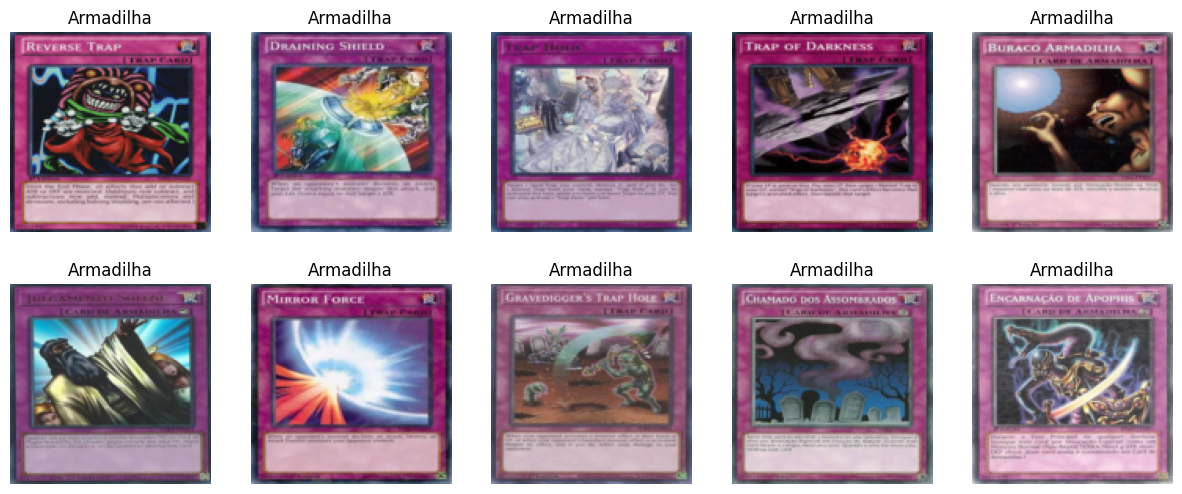

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
  image, label = dataset[i]

  image = image.permute(1, 2, 0)

  ax.imshow(image)
  ax.set_title(dataset.classes[label])
  ax.axis('off')


plt.show()

Criando a Rede Neural

In [8]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

    self.pool = nn.MaxPool2d(2, 2)
    self.fc1 = nn.Linear(64 * 16 * 16, 128)
    self.fc2 = nn.Linear(128, 9)

  def forward(self, x):

    x = self.pool(torch.relu(self.conv1(x)))
    x = self.pool(torch.relu(self.conv2(x)))
    x = self.pool(torch.relu(self.conv3(x)))

    x = x.view(x.size(0), -1)
    x = torch.relu(self.fc1(x))
    x = self.fc2(x)

    return x

In [9]:
model = CNN()
model = model.to(device)

print(model.forward)

<bound method CNN.forward of CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=9, bias=True)
)>


In [10]:
print(CNN.forward)
print(type(model).forward)
print(model.__class__ is CNN)

<function CNN.forward at 0x7cf758190040>
<function CNN.forward at 0x7cf758190040>
True


In [11]:
print("CNN.forward:")
print(CNN.forward)

print("\ntype(model).forward:")
print(type(model).forward)

print("\nA classe é a mesma?")
print(model.__class__ is CNN)

print("\nNome da classe do model:")
print(model.__class__.__name__)

print("\nMódulo da classe:")
print(model.__class__.__module__)

CNN.forward:
<function CNN.forward at 0x7cf758190040>

type(model).forward:
<function CNN.forward at 0x7cf758190040>

A classe é a mesma?
True

Nome da classe do model:
CNN

Módulo da classe:
__main__


Criando o dataLoader

In [12]:
train_loader = DataLoader(
    dataset, batch_size=32, shuffle=True
    )

Criando o Optimizer

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(), lr=0.001
    )

Treinando o modelo

In [34]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Época {epoch + 1}/{num_epochs} "
        f"- Loss: {running_loss / len(train_loader):.4f}"
    )

Época 1/10 - Loss: 0.0006
Época 2/10 - Loss: 0.0005
Época 3/10 - Loss: 0.0005
Época 4/10 - Loss: 0.0005
Época 5/10 - Loss: 0.0005
Época 6/10 - Loss: 0.0005
Época 7/10 - Loss: 0.0005
Época 8/10 - Loss: 0.0005
Época 9/10 - Loss: 0.0004
Época 10/10 - Loss: 0.0004


Dividindo o DataSet

In [15]:
from torch.utils.data import random_split

tamanho_treino = int(0.8 * len(dataset))
tamanho_teste = len(dataset) - tamanho_treino

treino_dataset, val_dataset = random_split (
    dataset, [tamanho_treino, tamanho_teste]
)

print("Imagens Treino: ", len(treino_dataset))
print("Imagens Validação: ", len(val_dataset))

Imagens Treino:  72
Imagens Validação:  18


Criando os DataLoaders

In [16]:
treino_loader = DataLoader(
    treino_dataset, batch_size=32, shuffle=True
    )

val_loader = DataLoader(
    val_dataset, batch_size=32, shuffle=False
    )

Recriando a CNN, para que o resultado seja justo

In [17]:
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

Treinando novamente o modelo, agora dividindo entre aprendizagem e validação

In [35]:
num_epochs = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()

    running_train_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)
    val_losses.append(val_loss)


    print(
        f"Época {epoch + 1}/{num_epochs} "
        f"- Train Loss: {train_loss:.4f} "
        f"- Val Loss: {val_loss:.4f}"
    )

Época 1/10 - Train Loss: 0.0004 - Val Loss: 0.0003
Época 2/10 - Train Loss: 0.0004 - Val Loss: 0.0003
Época 3/10 - Train Loss: 0.0004 - Val Loss: 0.0003
Época 4/10 - Train Loss: 0.0004 - Val Loss: 0.0003
Época 5/10 - Train Loss: 0.0004 - Val Loss: 0.0003
Época 6/10 - Train Loss: 0.0004 - Val Loss: 0.0003
Época 7/10 - Train Loss: 0.0004 - Val Loss: 0.0003
Época 8/10 - Train Loss: 0.0004 - Val Loss: 0.0003
Época 9/10 - Train Loss: 0.0003 - Val Loss: 0.0002
Época 10/10 - Train Loss: 0.0003 - Val Loss: 0.0002


Testando a assertividade do modelo

In [28]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Assertividade: {accuracy:2f}%")

Assertividade: 100.000000%


Criando a interação com o usuário, para que ele descubra o tipo da carta que tem

Saving GMX.jpeg to GMX.jpeg


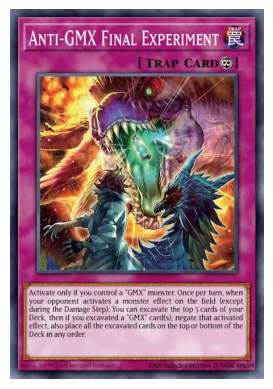

Tipo da carta:  Armadilha


In [39]:
from google.colab import files
from PIL import Image
import torch
import matplotlib.pyplot as plt

uploaded = files.upload()

arquivo_nome = list(uploaded.keys())[0]

image = Image.open(arquivo_nome)

plt.imshow(image)
plt.axis('off')
plt.show()

imagem_processada = transform(image).unsqueeze(0)

imagem_processada = imagem_processada.to(device)

model.eval()

with torch.no_grad():
  output = model(imagem_processada)

  _, classe_prevista = torch.max(output, 1)

  nome_classe = dataset.classes[classe_prevista.item()]

  print("Tipo da carta: ", nome_classe)

In [23]:
from collections import Counter

model.eval()

previsoes = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        previsoes.extend(predicted.cpu().numpy())

contagem_previsoes = Counter(previsoes)

for indice, quantidade in sorted(contagem_previsoes.items()):
    print(dataset.classes[indice], quantidade)

Armadilha 3
Efeito 1
Fusão 2
Link 2
Magia 2
Ritual 3
Sincro 4
XYZ 1
